## Load Adult Census Dataset Using SHAP

In this notebook (repository), we load Adult Census dataset using SHAP library, review the dataset, transform it, and upload it to Amazon S3.

In [2]:
import shap

X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)
feature_names = list(X.columns)
feature_names

['Age',
 'Workclass',
 'Education-Num',
 'Marital Status',
 'Occupation',
 'Relationship',
 'Race',
 'Sex',
 'Capital Gain',
 'Capital Loss',
 'Hours per week',
 'Country']

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581646,3.868892,10.080679,2.611836,6.572740,2.494518,3.665858,0.669205,1077.648804,87.303833,40.437454,36.718866
std,13.640442,1.455960,2.572562,1.506222,4.228857,1.758232,0.848806,0.470506,7385.911621,403.014771,12.347933,7.823782
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,4.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,39.000000
50%,37.000000,4.000000,10.000000,2.000000,7.000000,3.000000,4.000000,1.000000,0.000000,0.000000,40.000000,39.000000
75%,48.000000,4.000000,12.000000,4.000000,10.000000,4.000000,4.000000,1.000000,0.000000,0.000000,45.000000,39.000000
max,90.000000,8.000000,16.000000,6.000000,14.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000


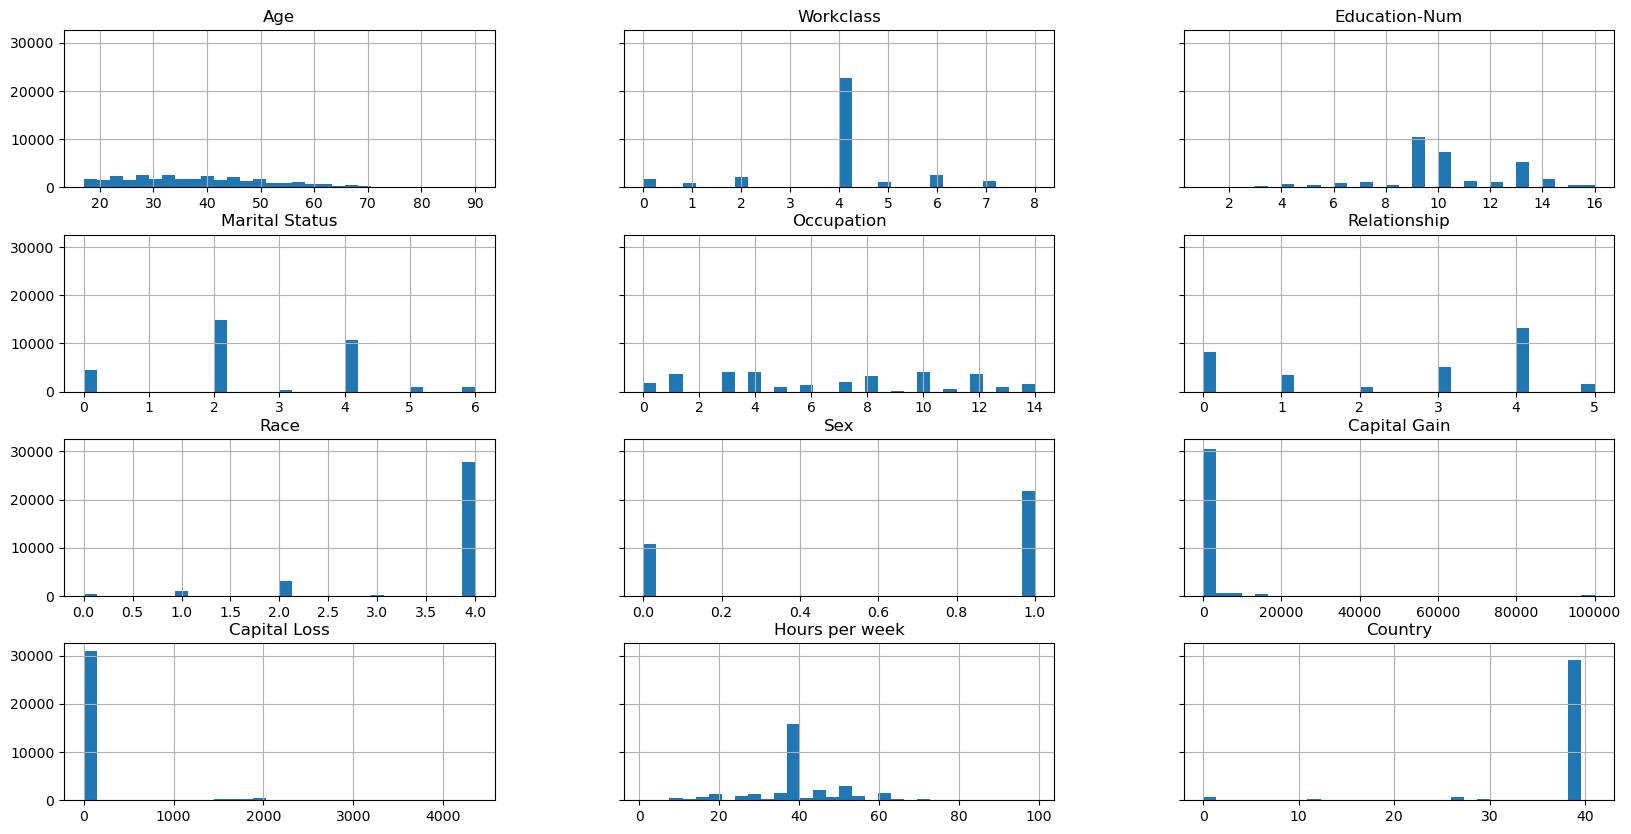

In [6]:
display(X.describe())
hist = X.hist(bins=30, sharey=True, figsize=(20, 10))

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_display = X_display.loc[X_train.index]

In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)
X_train_display = X_display.loc[X_train.index]
X_val_display = X_display.loc[X_val.index]

In [16]:
import pandas as pd
train = pd.concat([pd.Series(y_train, index=X_train.index,
                             name='Income>50K', dtype=int), X_train], axis=1)
validation = pd.concat([pd.Series(y_val, index=X_val.index,
                            name='Income>50K', dtype=int), X_val], axis=1)
test = pd.concat([pd.Series(y_test, index=X_test.index,
                            name='Income>50K', dtype=int), X_test], axis=1)

In [17]:
train

,Income>50K,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
13991,1,33.0,4,15.0,4,10,0,4,1,0.0,0.0,40.0,39
13715,0,20.0,4,9.0,4,12,3,4,0,0.0,0.0,30.0,39
13130,1,51.0,2,13.0,2,10,5,4,0,0.0,0.0,40.0,39
3066,0,20.0,4,10.0,4,14,3,4,1,0.0,0.0,30.0,39
9134,1,38.0,2,9.0,2,3,4,4,1,0.0,0.0,50.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17294,0,41.0,4,9.0,2,7,4,4,1,0.0,0.0,45.0,39
18399,0,39.0,5,13.0,2,12,4,4,1,0.0,0.0,40.0,39
7731,0,37.0,4,9.0,2,6,4,4,1,0.0,0.0,24.0,39
28246,1,47.0,6,10.0,2,13,4,2,1,0.0,0.0,40.0,39


In [18]:
validation

,Income>50K,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
29286,0,38.0,4,4.0,2,1,4,4,1,0.0,0.0,40.0,39
21648,0,69.0,0,4.0,2,0,4,4,1,0.0,0.0,48.0,39
26774,0,37.0,4,2.0,4,8,1,4,0,0.0,0.0,48.0,8
13333,0,23.0,4,13.0,4,10,3,4,0,0.0,0.0,40.0,39
8654,0,30.0,4,9.0,4,11,0,4,1,0.0,0.0,99.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23567,1,48.0,5,13.0,2,4,4,4,1,0.0,0.0,60.0,39
13496,0,34.0,4,13.0,4,10,0,4,1,2463.0,0.0,50.0,10
10232,0,21.0,0,9.0,2,0,2,4,0,0.0,0.0,35.0,39
25212,0,52.0,1,10.0,2,1,4,4,1,0.0,0.0,40.0,39


In [19]:
test

,Income>50K,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
14160,0,27.0,4,10.0,0,1,0,4,0,0.0,0.0,38.0,39
27048,0,45.0,7,9.0,2,4,5,4,0,0.0,0.0,40.0,39
28868,1,29.0,4,13.0,2,4,4,2,1,0.0,0.0,55.0,39
5667,0,30.0,4,13.0,4,7,0,4,0,0.0,0.0,40.0,39
7827,0,29.0,6,10.0,0,3,0,4,1,2202.0,0.0,50.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,0,71.0,4,13.0,0,13,3,4,0,2329.0,0.0,16.0,39
24534,1,55.0,2,10.0,2,10,4,4,1,0.0,0.0,40.0,39
18080,1,47.0,4,15.0,2,10,4,4,1,99999.0,0.0,48.0,39
10354,0,27.0,4,13.0,4,1,0,4,0,0.0,0.0,40.0,39


## Convert the Train and Validation Datasets to CSV Files

Convert the train and validation dataframe objects to CSV files to match the input file format for the XGBoost algorithm.

In [21]:
train.to_csv("train.csv", index=False, header=False)
validation.to_csv("validation.csv", index=False, header=False)

In [23]:
import sagemaker, boto3, os
bucket = sagemaker.Session().default_bucket()
prefix = "sagemaker-xgboost-adult-income-prediction"

# Save the train.csv file into data folder in S3
boto3.Session().resource("s3").Bucket(bucket).Object(os.path.join(prefix, "data/train.csv")).upload_file("train.csv")

# Save the validation.csv file into data folder in S3
boto3.Session().resource("s3").Bucket(bucket).Object(os.path.join(prefix, "data/validation.csv")).upload_file("validation.csv")

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/12/25 21:53:31] INFO     Found credentials from IAM Role:                                   ]8;id=799876;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=859161;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


[02/12/25 21:53:36] INFO     Found credentials from IAM Role:                                   ]8;id=660105;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=268042;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

[02/12/25 21:53:37] INFO     Found credentials from IAM Role:                                   ]8;id=136136;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=883778;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=62637;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=642013;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

In [24]:
! aws s3 ls {bucket}/{prefix}/data --recursive

2025-02-12 21:53:38     786069 sagemaker-xgboost-adult-income-prediction/data/train.csv
2025-02-12 21:53:38     262088 sagemaker-xgboost-adult-income-prediction/data/validation.csv


## Train a Model

We use XGBoost algorithm to train on our model.
https://docs.aws.amazon.com/sagemaker/latest/dg/xgboost.html

#### Retrieving the basic information

In [26]:
import sagemaker

region = sagemaker.Session().boto_region_name
print(f"AWS Region: {region}")

role = sagemaker.get_execution_role()
print(f"RoleArn: {role}")

[02/12/25 22:01:31] INFO     Found credentials from IAM Role:                                   ]8;id=675874;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=560687;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

AWS Region: ca-central-1


                    INFO     Found credentials from IAM Role:                                   ]8;id=522476;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=879360;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

RoleArn: arn:aws:iam::445567102787:role/service-role/AmazonSageMaker-ExecutionRole-20250212T161774


In [30]:
from sagemaker.debugger import Rule, ProfilerRule, rule_configs
from sagemaker.session import TrainingInput

s3_output_location = f"s3://{bucket}/{prefix}/xgboost_model"

container = sagemaker.image_uris.retrieve("xgboost", region, "1.2-1")
print(container)

xgb_model = sagemaker.estimator.Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type="ml.m4.xlarge",
    volume_size=5,
    output_path=s3_output_location,
    sagemaker_session=sagemaker.Session(),
    rules=[Rule.sagemaker(rule_configs.create_xgboost_report()),
           ProfilerRule.sagemaker(rule_configs.ProfilerReport())
    ]
)

[02/12/25 22:11:18] INFO     Ignoring unnecessary instance type: None.                            ]8;id=798025;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=274100;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#528\528]8;;\

341280168497.dkr.ecr.ca-central-1.amazonaws.com/sagemaker-xgboost:1.2-1


                    INFO     Found credentials from IAM Role:                                   ]8;id=457771;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=791341;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=647016;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=391828;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

In [31]:
xgb_model.set_hyperparameters(
    max_depth = 5,
    eta = 0.2,
    gamma = 4,
    min_child_weight = 6,
    subsample = 0.7,
    objective = "binary:logistic",
    num_round = 1000
)

In [35]:
from sagemaker.session import TrainingInput

train_input = TrainingInput(
    f"s3://{bucket}/{prefix}/data/train.csv", content_type="csv"
)
validation_input = TrainingInput(
    f"s3://{bucket}/{prefix}/data/validation.csv", content_type="csv"
)

In [36]:
xgb_model.fit({"train": train_input, "validation": validation_input}, wait=True)

[02/12/25 22:15:34] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=123929;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=943123;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name:                                       ]8;id=920944;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=687686;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\
                             sagemaker-xgboost-2025-02-12-22-15-34-374                                             

2025-02-12 22:15:37 Starting - Starting the training job...
2025-02-12 22:16:03 Starting - Preparing the instances for trainingCreateXgboostReport: InProgress
ProfilerReport: InProgress
..
..25-02-12 22:16:39 Downloading - Downloading input data.
..25-02-12 22:17:03 Downloading - Downloading the training image.
.[2025-02-12 22:17:49.807 ip-10-0-105-44.ca-central-1.compute.internal:7 INFO utils.py:27] RULE_JOB_STOP_SIGNAL_FILENAME: None
INFO:sagemaker-containers:Imported framework sagemaker_xgboost_container.training
INFO:sagemaker-containers:Failed to parse hyperparameter objective value binary:logistic to Json.
Returning the value itself
INFO:sagemaker-containers:No GPUs detected (normal if no gpus installed)
INFO:sagemaker_xgboost_container.training:Running XGBoost Sagemaker in algorithm mode
INFO:root:Determined delimiter of CSV input is ','
INFO:root:Determined delimiter of CSV input is ','
INFO:root:Determined delimiter of CSV input is ','
INFO:root:Determined delimiter of CSV inp

In [37]:
rule_output_path = xgb_model.output_path + "/" + xgb_model.latest_training_job.job_name + "/rule-output"
! aws s3 ls {rule_output_path} --recursive

2025-02-12 22:18:50        316 sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/ConfusionMatrix.json
2025-02-12 22:18:50        733 sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/EvaluationMetrics.json
2025-02-12 22:18:50       2685 sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/FeatureImportance.json
2025-02-12 22:18:50       9585 sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/IterativeClassAccuracy.json
2025-02-12 22:18:50        180 sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/LabelsDistribution.j

In [38]:
! aws s3 cp {rule_output_path} ./ --recursive

download: s3://sagemaker-ca-central-1-445567102787/sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/ConfusionMatrix.json to CreateXgboostReport/xgboost-reports/ConfusionMatrix.json
download: s3://sagemaker-ca-central-1-445567102787/sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json to ProfilerReport/profiler-output/profiler-reports/BatchSize.json
download: s3://sagemaker-ca-central-1-445567102787/sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/rule-output/CreateXgboostReport/xgboost-reports/EvaluationMetrics.json to CreateXgboostReport/xgboost-reports/EvaluationMetrics.json
download: s3://sagemaker-ca-central-1-445567102787/sagemaker-xgboost-adult-income-prediction/xgboost_model/sagemaker-xgboost-2025-02-12-22-15-34-374/r

In [39]:
from IPython.display import FileLink, FileLinks
display("Click link below to view the XGBoost Training report", FileLink("CreateXgboostReport/xgboost_report.html"))

'Click link below to view the XGBoost Training report'

/home/ec2-user/SageMaker/CreateXgboostReport/xgboost_report.html

In [40]:
profiler_report_name = [rule["RuleConfigurationName"] 
                        for rule in xgb_model.latest_training_job.rule_job_summary() 
                        if "Profiler" in rule["RuleConfigurationName"]][0]
profiler_report_name
display("Click link below to view the profiler report", FileLink(profiler_report_name+"/profiler-output/profiler-report.html"))

'Click link below to view the profiler report'

/home/ec2-user/SageMaker/ProfilerReport/profiler-output/profiler-report.html

## Deploy the Model

In [41]:
import sagemaker
from sagemaker.serializers import CSVSerializer
xgb_predictor=xgb_model.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',
    serializer=CSVSerializer()
)

[02/12/25 22:21:09] INFO     Creating model with name: sagemaker-xgboost-2025-02-12-22-21-09-489    ]8;id=615392;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=733862;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\

[02/12/25 22:21:10] INFO     Creating endpoint-config with name                                     ]8;id=126843;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=629543;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#5889\5889]8;;\
                             sagemaker-xgboost-2025-02-12-22-21-09-489                                             

                    INFO     Creating endpoint with name sagemaker-xgboost-2025-02-12-22-21-09-489  ]8;id=659162;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=698376;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4711\4711]8;;\

-----------!

In [42]:
xgb_predictor.endpoint_name

'sagemaker-xgboost-2025-02-12-22-21-09-489'

In [43]:
X_test.to_csv('test.csv', index=False, header=False)

boto3.Session().resource('s3').Bucket(bucket).Object(
os.path.join(prefix, 'test/test.csv')).upload_file('test.csv')

[02/12/25 22:27:11] INFO     Found credentials from IAM Role:                                   ]8;id=894065;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=814781;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

In [44]:
# The location of the test dataset
batch_input = 's3://{}/{}/test'.format(bucket, prefix)

# The location to store the results of the batch transform job
batch_output = 's3://{}/{}/batch-prediction'.format(bucket, prefix)

In [45]:
transformer = xgb_model.transformer(
    instance_count=1, 
    instance_type='ml.m4.xlarge', 
    output_path=batch_output
)

[02/12/25 22:27:12] INFO     Creating model with name: sagemaker-xgboost-2025-02-12-22-27-12-155    ]8;id=282803;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=482022;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\

In [46]:
transformer.transform(
    data=batch_input, 
    data_type='S3Prefix',
    content_type='text/csv', 
    split_type='Line'
)
transformer.wait()

                    INFO     Creating transform job with name:                                      ]8;id=278721;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=288733;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#3951\3951]8;;\
                             sagemaker-xgboost-2025-02-12-22-27-12-787                                             

...................................[2025-02-12:22:33:01:INFO] No GPUs detected (normal if no gpus installed)
[2025-02-12:22:33:01:INFO] No GPUs detected (normal if no gpus installed)
[2025-02-12:22:33:01:INFO] No GPUs detected (normal if no gpus installed)
[2025-02-12:22:33:01:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocations|execution-parameters) {
      proxy_set_header X-Forwarded-For $proxy_add_x_forwarded_for;
      proxy_set_header Host $http_host;
      proxy_redirect off;
      proxy_read_timeout 60s;
      proxy_pass http://gunicorn;
    }
    location / {
      retu

In [47]:
! aws s3 cp {batch_output} ./ --recursive

download: s3://sagemaker-ca-central-1-445567102787/sagemaker-xgboost-adult-income-prediction/batch-prediction/test.csv.out to ./test.csv.out


## Evaluation of the Model

In [48]:
import numpy as np
def predict(data, rows=1000):
    split_array = np.array_split(data, int(data.shape[0] / float(rows) + 1))
    predictions = ''
    for array in split_array:
        predictions = ','.join([predictions, xgb_predictor.predict(array).decode('utf-8')])
    return np.fromstring(predictions[1:], sep=',')

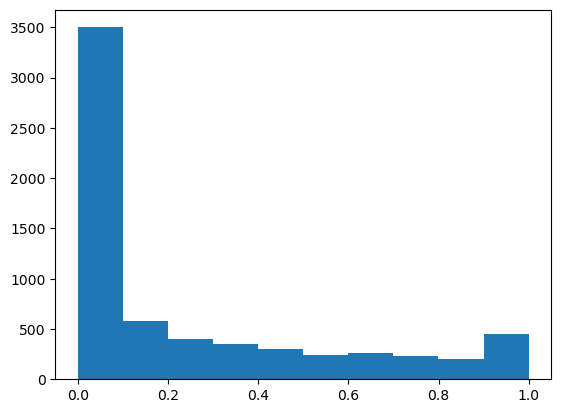

In [49]:
import matplotlib.pyplot as plt

predictions=predict(test.to_numpy()[:,1:])
plt.hist(predictions)
plt.show()

In [50]:
import sklearn

cutoff=0.5
print(sklearn.metrics.confusion_matrix(test.iloc[:, 0], np.where(predictions > cutoff, 1, 0)))
print(sklearn.metrics.classification_report(test.iloc[:, 0], np.where(predictions > cutoff, 1, 0)))

[[4626  316]
 [ 504 1067]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.77      0.68      0.72      1571

    accuracy                           0.87      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.87      0.87      6513



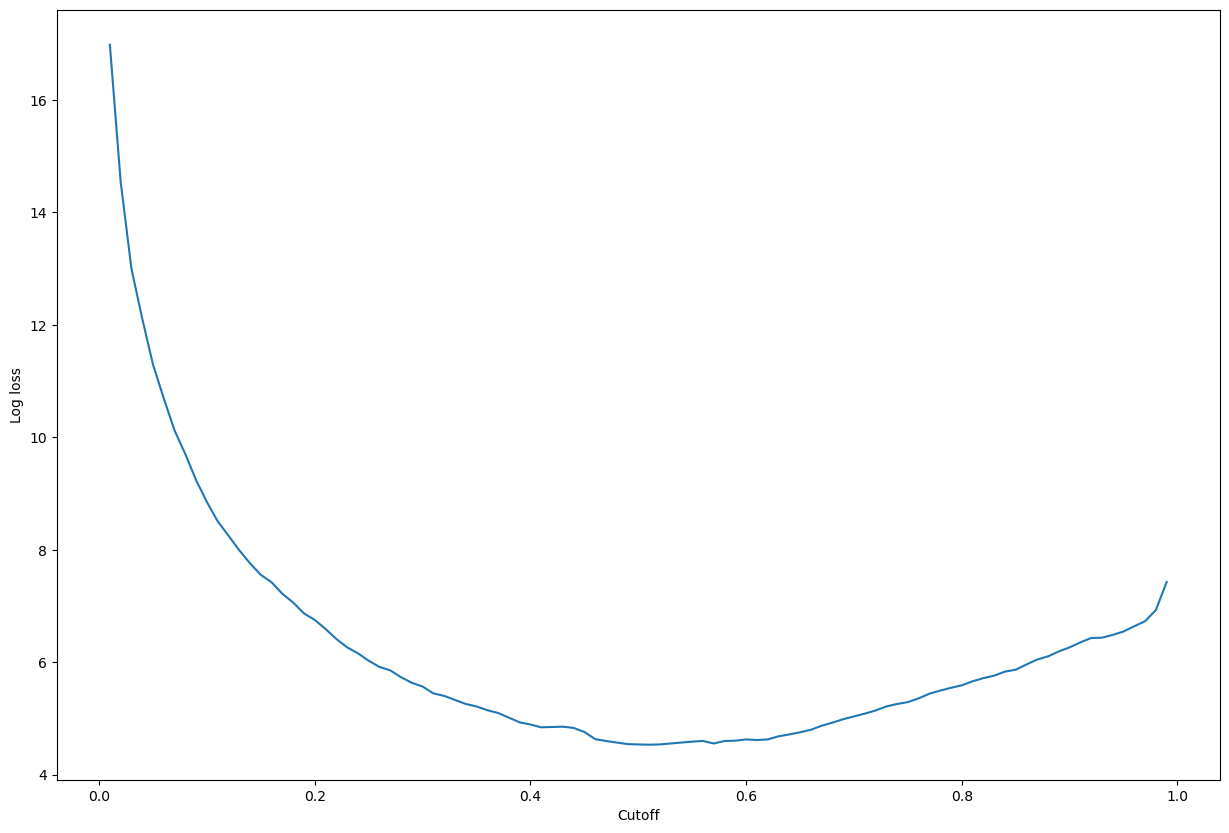

In [51]:
import matplotlib.pyplot as plt

cutoffs = np.arange(0.01, 1, 0.01)
log_loss = []
for c in cutoffs:
    log_loss.append(
        sklearn.metrics.log_loss(test.iloc[:, 0], np.where(predictions > c, 1, 0))
    )

plt.figure(figsize=(15,10))
plt.plot(cutoffs, log_loss)
plt.xlabel("Cutoff")
plt.ylabel("Log loss")
plt.show()